In [1]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sms
import pandas as pd

%matplotlib inline

In [3]:
df_airline=pd.read_csv('airline_passengers.csv')
df_airline.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [4]:
df_airline.isnull().sum()

Month                      0
Thousands of Passengers    1
dtype: int64

In [5]:
df_airline.tail()

,Month,Thousands of Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [6]:
df_airline.dropna(axis=0,inplace=True)

In [7]:
df_airline.isnull().sum()

Month                      0
Thousands of Passengers    0
dtype: int64

In [8]:
df_airline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    144 non-null    object 
 1   Thousands of Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.4+ KB


In [9]:
df_airline['Month']=pd.to_datetime(df_airline['Month'])

In [10]:
df_airline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Month                    144 non-null    datetime64[ns]
 1   Thousands of Passengers  144 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.4 KB


In [11]:
df_airline.head()

,Month,Thousands of Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [12]:
df_airline.set_index('Month',inplace=True)

In [13]:
df_airline.head()

,Thousands of Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


<Axes: xlabel='Month'>

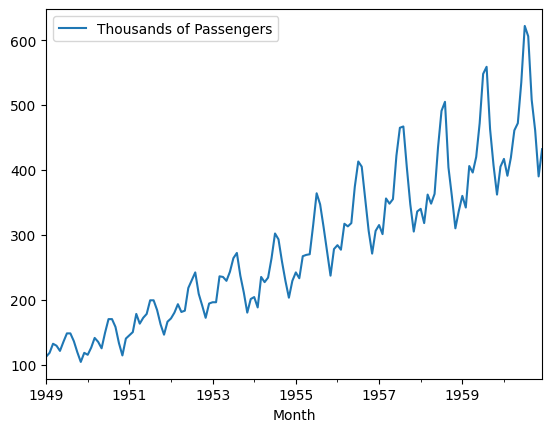

In [14]:
df_airline.plot()

In [15]:
from statsmodels.tsa.stattools import adfuller

In [16]:
def adf_test(series):
    result=adfuller(series, result_object=True)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [17]:
adf_test(df_airline['Thousands of Passengers'])

ADF Statistics: 0.8153688792060482
p- value: 0.991880243437641
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [18]:
## Use Techniques Differencing
df_airline['Passengers First Difference']=df_airline['Thousands of Passengers']-df_airline['Thousands of Passengers'].shift(1)

In [19]:
df_airline.head()

,Thousands of Passengers,Passengers First Difference
Month,,
1949-01-01,112.0,NaN
1949-02-01,118.0,6.0
1949-03-01,132.0,14.0
1949-04-01,129.0,-3.0
1949-05-01,121.0,-8.0


In [20]:
adf_test(df_airline['Passengers First Difference'].dropna())

ADF Statistics: -2.8292668241699994
p- value: 0.0542132902838255
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [21]:
## Use Techniques Differencing
df_airline['Passengers Second Difference']=df_airline['Passengers First Difference']-df_airline['Passengers First Difference'].shift(1)

In [22]:
adf_test(df_airline['Passengers Second Difference'].dropna())

ADF Statistics: -16.384231542468505
p- value: 2.7328918500142407e-29
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [23]:
### 12 months 
## Use Techniques Differencing
df_airline['Passengers 12 Difference']=df_airline['Thousands of Passengers']-df_airline['Thousands of Passengers'].shift(12)

In [24]:
adf_test(df_airline['Passengers 12 Difference'].dropna())

ADF Statistics: -3.383020726492481
p- value: 0.011551493085514954
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


| Cell | p-value                                  | Result                         |
| ---- | ---------------------------------------- | ------------------------------ |
| 20   | 0.0542                                   | Non-stationary at the 5% level |
| 22   | 2.73×10−292.73 \\times 10^{-29}2.73×10−29 | Stationary                     |
| 24   | 0.01155                                  | Stationary                     |


In [25]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

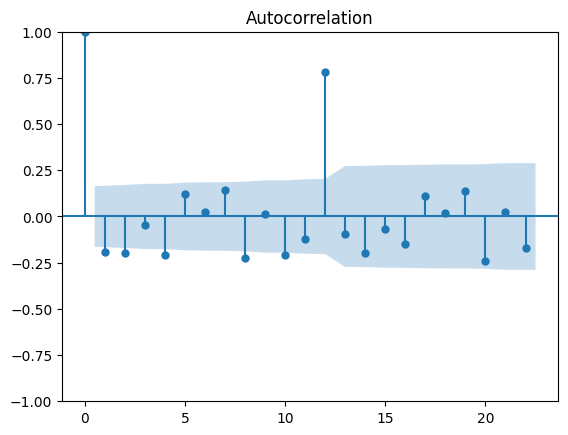

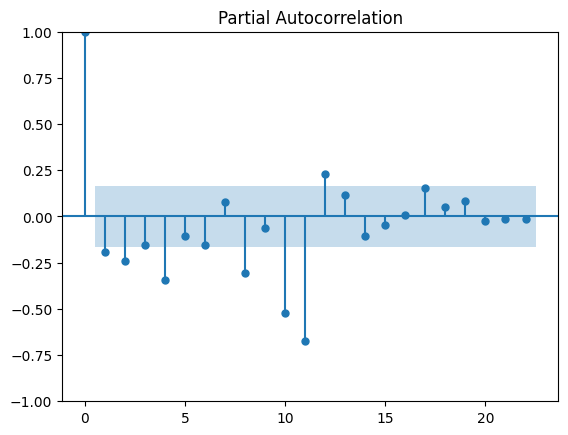

In [26]:
acf = plot_acf(df_airline["Passengers Second Difference"].dropna())
pacf1 = plot_pacf(df_airline["Passengers Second Difference"].dropna())

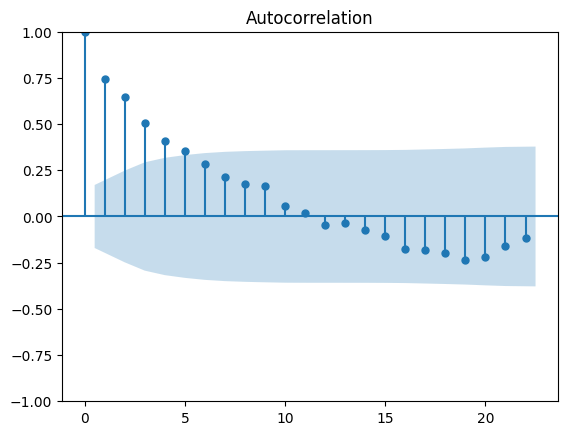

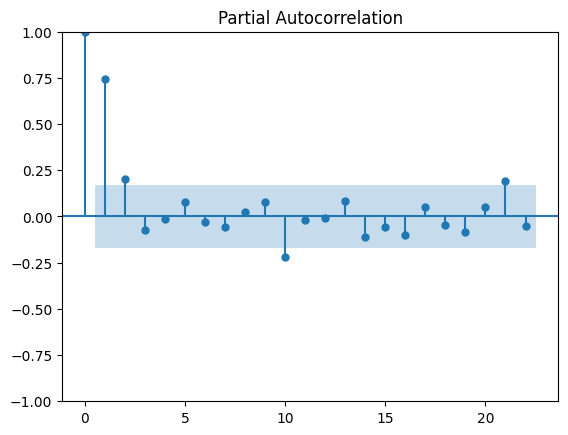

In [27]:
acf12 = plot_acf(df_airline["Passengers 12 Difference"].dropna())
pacf12 = plot_pacf(df_airline["Passengers 12 Difference"].dropna())

In [28]:
### split train and test data
df_airline

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN
...,...,...,...,...
1960-08-01,606.0,-16.0,-103.0,47.0
1960-09-01,508.0,-98.0,-82.0,45.0
1960-10-01,461.0,-47.0,51.0,54.0


In [29]:
from datetime import datetime,timedelta
train_dataset_end=datetime(1955,12,1)
test_dataset_end=datetime(1960,12,1)

In [30]:
train_data=df_airline[:train_dataset_end]
test_data=df_airline[train_dataset_end+timedelta(days=1):test_dataset_end]

In [31]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]

In [32]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1956-01-01,284.0,6.0,-35.0,42.0
1956-02-01,277.0,-7.0,-13.0,44.0
1956-03-01,317.0,40.0,47.0,50.0
1956-04-01,313.0,-4.0,-44.0,44.0
1956-05-01,318.0,5.0,9.0,48.0
1956-06-01,374.0,56.0,51.0,59.0
1956-07-01,413.0,39.0,-17.0,49.0
1956-08-01,405.0,-8.0,-47.0,58.0
1956-09-01,355.0,-50.0,-42.0,43.0


In [33]:
## create a ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [34]:
train_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN
...,...,...,...,...
1955-08-01,347.0,-17.0,-66.0,54.0
1955-09-01,312.0,-35.0,-18.0,53.0
1955-10-01,274.0,-38.0,-3.0,45.0


In [35]:
model_ARIMA=ARIMA(train_data['Thousands of Passengers'],order=(8,2,4))
# Candidate q values from the ACF plot of the second-order differenced series: 2, 3, and 4.
# Candidate p values from the PACF plot of the second-order differenced series: 2, 4, 8, 10, 11, and 12.

C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [36]:
model_Arima_fit=model_ARIMA.fit()

C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [37]:
model_Arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                      ARIMA(8, 2, 4)   Log Likelihood                -338.862
Date:                     Sat, 19 Sep 2026   AIC                            703.724
Time:                             22:39:26   BIC                            735.012
Sample:                         01-01-1949   HQIC                           716.286
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2292      0.109     -2.093      0.036      -0.444      -0.015
ar.L2         -0.1348      0.132     -1.020      0.308      -0.394       0.124
ar.L3          0.1860      0.138      1.349      0.177      -0.084       0.456
ar.L4         -0.5373      0.140     -3.844      0.000      -0.811      -0.263
ar.L5         -0.0459      0.129     -0.355      0.723      -0.300       0.208
ar.L6         -0.1146      0.119     -0.963      0.335      -0.348       0.119
ar.L7         -0.0629      0.140     -0.451      0.652      -0.337       0.211
ar.L8         -0.5684      0.153     -3.711      0.000      -0.869      -0.268
ma.L1         -0.5865      0.988     -0.594      0.553      -2.523       1.350
ma.L2         -0.6980      0.404     -1.727      0.084      -1.490       0.094
ma.L3         -0.6532      1.655     -0.395      0.693      -3.896       2.590
ma.L4          0.9421      1.143      0.824      0.410      -1.299       3.183
sigma2       176.4686    203.659      0.866      0.386    -222.696     575.633
===================================================================================
Ljung-Box (L1) (Q):                   0.42   Jarque-Bera (JB):                 2.77
Prob(Q):                              0.52   Prob(JB):                         0.25
Heteroskedasticity (H):               2.64   Skew:                             0.45
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [38]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1956-01-01,284.0,6.0,-35.0,42.0
1956-02-01,277.0,-7.0,-13.0,44.0
1956-03-01,317.0,40.0,47.0,50.0
1956-04-01,313.0,-4.0,-44.0,44.0
1956-05-01,318.0,5.0,9.0,48.0
1956-06-01,374.0,56.0,51.0,59.0
1956-07-01,413.0,39.0,-17.0,49.0
1956-08-01,405.0,-8.0,-47.0,58.0
1956-09-01,355.0,-50.0,-42.0,43.0


In [39]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [40]:
pred=model_Arima_fit.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data['Thousands of Passengers']-pred

In [41]:
pred

1956-01-01    298.466977
1956-02-01    276.193500
1956-03-01    263.193863
1956-04-01    274.400148
1956-05-01    288.615249
1956-06-01    317.216724
1956-07-01    340.471687
1956-08-01    311.995488
1956-09-01    309.339616
1956-10-01    319.814932
1956-11-01    309.252485
1956-12-01    318.988490
1957-01-01    315.851037
1957-02-01    298.858784
1957-03-01    304.589683
1957-04-01    320.919923
1957-05-01    322.073659
1957-06-01    329.073009
1957-07-01    339.331257
1957-08-01    329.353740
1957-09-01    337.914557
1957-10-01    348.347964
1957-11-01    338.226413
1957-12-01    340.994761
1958-01-01    342.782187
1958-02-01    336.166798
1958-03-01    342.262535
1958-04-01    350.534185
1958-05-01    346.665935
1958-06-01    350.962914
1958-07-01    359.970103
1958-08-01    356.484501
1958-09-01    362.798337
1958-10-01    369.323794
1958-11-01    363.279529
1958-12-01    366.997749
1959-01-01    371.367850
1959-02-01    367.864744
1959-03-01    371.624227
1959-04-01    376.693516


In [42]:
residuals

Month
1956-01-01    -14.466977
1956-02-01      0.806500
1956-03-01     53.806137
1956-04-01     38.599852
1956-05-01     29.384751
1956-06-01     56.783276
1956-07-01     72.528313
1956-08-01     93.004512
1956-09-01     45.660384
1956-10-01    -13.814932
1956-11-01    -38.252485
1956-12-01    -12.988490
1957-01-01     -0.851037
1957-02-01      2.141216
1957-03-01     51.410317
1957-04-01     27.080077
1957-05-01     32.926341
1957-06-01     92.926991
1957-07-01    125.668743
1957-08-01    137.646260
1957-09-01     66.085443
1957-10-01     -1.347964
1957-11-01    -33.226413
1957-12-01     -4.994761
1958-01-01     -2.782187
1958-02-01    -18.166798
1958-03-01     19.737465
1958-04-01     -2.534185
1958-05-01     16.334065
1958-06-01     84.037086
1958-07-01    131.029897
1958-08-01    148.515499
1958-09-01     41.201663
1958-10-01    -10.323794
1958-11-01    -53.279529
1958-12-01    -29.997749
1959-01-01    -11.367850
1959-02-01    -25.864744
1959-03-01     34.375773
1959-04-01     19.3

<Axes: ylabel='Density'>

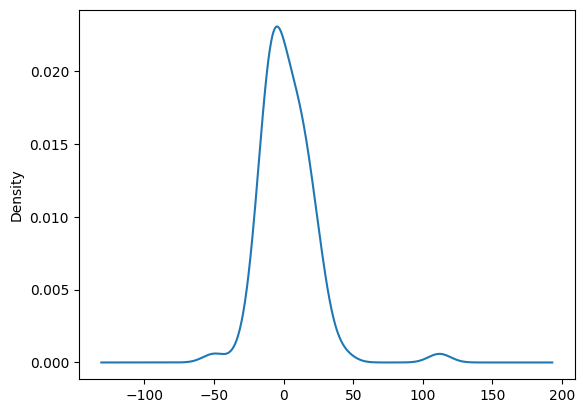

In [43]:
model_Arima_fit.resid.plot(kind='kde')

In [44]:
import warnings
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

In [45]:
test_data['Predicted_ARIMA']=pred

<Axes: xlabel='Month'>

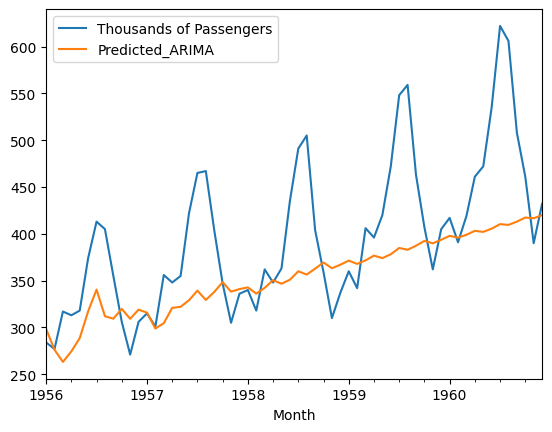

In [46]:
test_data[['Thousands of Passengers','Predicted_ARIMA']].plot()

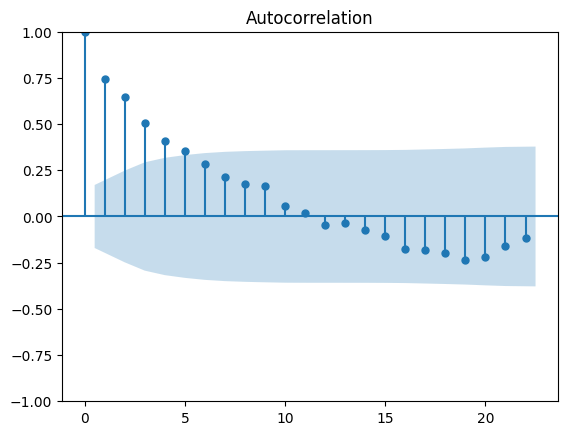

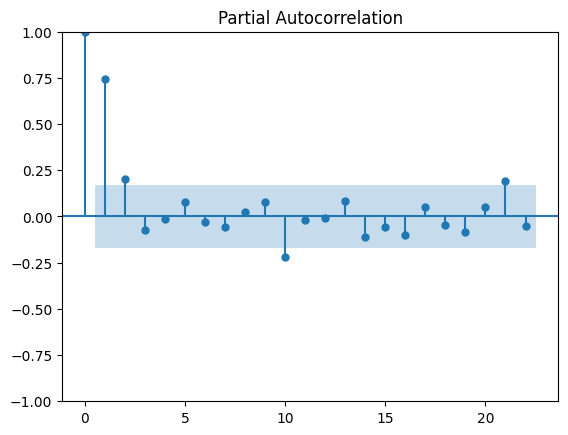

In [47]:
acf12 = plot_acf(df_airline["Passengers 12 Difference"].dropna())
pacf12 = plot_pacf(df_airline["Passengers 12 Difference"].dropna())

In [48]:
## create a SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [49]:
model_SARIMA=SARIMAX(train_data['Thousands of Passengers'],order=(3,0,5),seasonal_order=(0,1,0,12))
# Candidate q values from the ACF plot of the 12th-order differenced series: 1, 4, and 5.
# Candidate p values from the PACF plot of the 12th-order differenced series: 1, 2, and 3.

C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [50]:
model_SARIMA_fit=model_SARIMA.fit()

C:\Users\haris\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [51]:
model_SARIMA_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(3, 0, 5)x(0, 1, [], 12)   Log Likelihood                -265.240
Date:                             Sat, 19 Sep 2026   AIC                            548.481
Time:                                     22:39:27   BIC                            568.971
Sample:                                 01-01-1949   HQIC                           556.638
                                      - 12-01-1955                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5981      0.938      0.638      0.524      -1.240       2.436
ar.L2          0.8311      0.232      3.582      0.000       0.376       1.286
ar.L3         -0.4523      0.894     -0.506      0.613      -2.204       1.299
ma.L1          0.1839      1.164      0.158      0.874      -2.098       2.466
ma.L2         -0.5340      1.262     -0.423      0.672      -3.007       1.939
ma.L3         -0.0987      0.384     -0.257      0.797      -0.852       0.654
ma.L4         -0.1273      0.337     -0.377      0.706      -0.788       0.534
ma.L5          0.2471      0.357      0.693      0.488      -0.452       0.946
sigma2        87.7333     81.127      1.081      0.280     -71.272     246.739
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.68
Prob(Q):                              0.88   Prob(JB):                         0.26
Heteroskedasticity (H):               2.05   Skew:                             0.46
Prob(H) (two-sided):                  0.09   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
test_data.tail()

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference,Predicted_ARIMA
Month,,,,,
1960-08-01,606.0,-16.0,-103.0,47.0,409.500155
1960-09-01,508.0,-98.0,-82.0,45.0,412.981321
1960-10-01,461.0,-47.0,51.0,54.0,417.362170
1960-11-01,390.0,-71.0,-24.0,28.0,416.627255
1960-12-01,432.0,42.0,113.0,27.0,419.897694


In [53]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [54]:
pred_Sarima=model_SARIMA_fit.predict(start=datetime(1956,6,6),end=datetime(1960,12,1))
residuals=test_data['Thousands of Passengers']-pred_Sarima

<Axes: xlabel='Month'>

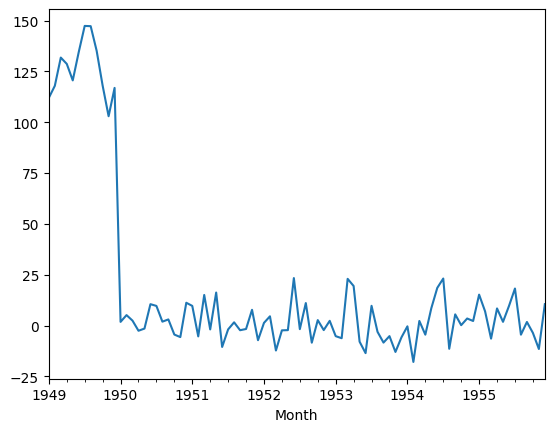

In [55]:
model_SARIMA_fit.resid.plot()

<Axes: ylabel='Density'>

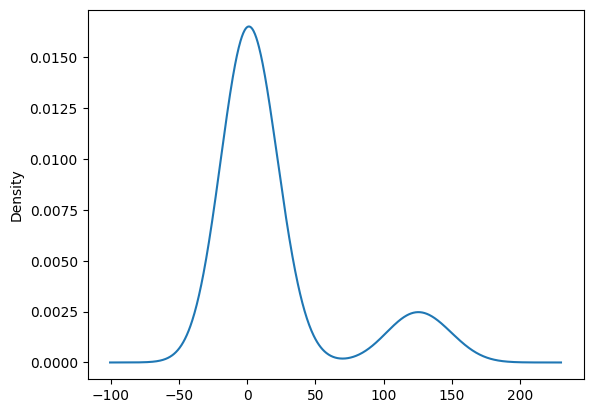

In [56]:
model_SARIMA_fit.resid.plot(kind='kde')

In [57]:
#test_data['Predicted_SARIMA']=pred_Sarima
test_data.loc[:, 'Predicted_SARIMA'] = pred_Sarima

In [58]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference,Predicted_ARIMA,Predicted_SARIMA
Month,,,,,,
1956-01-01,284.0,6.0,-35.0,42.0,298.466977,NaN
1956-02-01,277.0,-7.0,-13.0,44.0,276.193500,NaN
1956-03-01,317.0,40.0,47.0,50.0,263.193863,NaN
1956-04-01,313.0,-4.0,-44.0,44.0,274.400148,NaN
1956-05-01,318.0,5.0,9.0,48.0,288.615249,NaN
1956-06-01,374.0,56.0,51.0,59.0,317.216724,NaN
1956-07-01,413.0,39.0,-17.0,49.0,340.471687,403.397946
1956-08-01,405.0,-8.0,-47.0,58.0,311.995488,385.071040
1956-09-01,355.0,-50.0,-42.0,43.0,309.339616,349.445541


<Axes: xlabel='Month'>

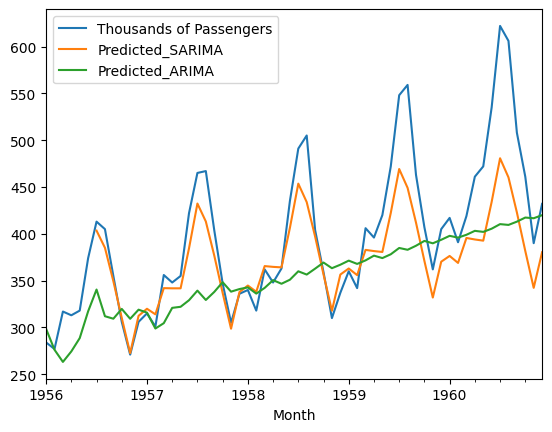

In [59]:
test_data[['Thousands of Passengers','Predicted_SARIMA','Predicted_ARIMA']].plot()